# DSA 210 — On Repeat: ML Pipeline
**Batuhan Dağcı | 34059**

**Goal:** Classify a day's `period` (exam_period vs regular, and 3-class) from aggregated daily **behavioural** listening features.

Feature scope: repetition, volume, and timing only. Audio proxies and mood tags are excluded — they belong to a different research question the data cannot support.

This notebook is independent of `eda.ipynb`.

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, make_scorer
)
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42
np.random.seed(SEED)

In [2]:
df_raw = pd.read_csv('data/streaming_clean.csv')
df_raw['ts']   = pd.to_datetime(df_raw['ts'], utc=True)
df_raw['date'] = pd.to_datetime(df_raw['date']).dt.date

print(f'Shape before filter: {df_raw.shape}')
print(f'Period distribution (full):\n{df_raw["period"].value_counts().to_string()}\n')

START = datetime.date(2025, 9, 15)
END   = datetime.date(2026, 1, 31)
df = df_raw[(df_raw['date'] >= START) & (df_raw['date'] <= END)].copy()

print(f'Shape after Fall 2025 filter ({START} to {END}): {df.shape}')
print(f'Period distribution (fall rows):\n{df["period"].value_counts().to_string()}')

Shape before filter: (14628, 13)
Period distribution (full):
period
regular     12855
pre_exam     1194
exam_day      579

Shape after Fall 2025 filter (2025-09-15 to 2026-01-31): (5329, 13)
Period distribution (fall rows):
period
regular     3556
pre_exam    1194
exam_day     579


## 2. Daily Feature Engineering

Features are restricted to **behavioural signals only**: repetition (`loop_ratio`), listening volume, and timing. Audio proxies and mood tags are not aggregated.

In [3]:
df_sorted = df.sort_values(['date', 'ts']).reset_index(drop=True)

def compute_loop_ratio(group):
    seen = set()
    loops = 0
    for _, row in group.iterrows():
        key = (row['artistName'], row['trackName'])
        if key in seen:
            loops += 1
        seen.add(key)
    return loops / len(group) if len(group) else 0.0

records = []
for date, grp in df_sorted.groupby('date'):
    n = len(grp)
    if n < 3:
        continue

    period_val = grp['period'].iloc[0]

    hour_counts = grp['hour'].value_counts()
    full_dist = np.zeros(24)
    for h, c in hour_counts.items():
        full_dist[int(h)] = c / n

    unique_tracks = grp.groupby(['artistName', 'trackName']).ngroups

    rec = {
        'date':                    date,
        'period_3class':           period_val,
        'period_binary':           'exam_period' if period_val in ('pre_exam', 'exam_day') else 'regular',
        'loop_ratio':              compute_loop_ratio(grp),
        'total_plays':             n,
        'unique_tracks':           unique_tracks,
        'unique_artists':          grp['artistName'].nunique(),
        'tracks_per_play':         unique_tracks / n,
        'avg_ms_played':           grp['msPlayed'].mean(),
        'median_ms_played':        grp['msPlayed'].median(),
        'std_ms_played':           grp['msPlayed'].std(),
        'total_listening_minutes': grp['msPlayed'].sum() / 60000,
        'night_play_ratio':        (grp['hour'].between(0, 6)).mean(),
        'morning_play_ratio':      (grp['hour'].between(7, 11)).mean(),
        'afternoon_play_ratio':    (grp['hour'].between(12, 17)).mean(),
        'evening_play_ratio':      (grp['hour'].between(18, 23)).mean(),
        'peak_hour':               int(grp['hour'].mode().iloc[0]),
        'hour_entropy':            stats.entropy(full_dist + 1e-12, base=2),
        'day_of_week_num':         int(grp['day_of_week_num'].iloc[0]),
        'is_weekend':              1 if int(grp['day_of_week_num'].iloc[0]) in (5, 6) else 0,
    }
    records.append(rec)

daily = pd.DataFrame(records)
daily.to_csv('data/streaming_daily.csv', index=False)

print(f'Daily rows: {len(daily)}')
print(f'Columns: {list(daily.columns)}')
print(f'\nperiod_3class:\n{daily["period_3class"].value_counts().to_string()}')
print(f'\nperiod_binary:\n{daily["period_binary"].value_counts().to_string()}')

if abs(daily[daily['period_3class'] == 'regular'].shape[0] - 104) > 5:
    print('WARNING: regular day count deviates from expected ~104!')
if abs(daily[daily['period_binary'] == 'exam_period'].shape[0] - 34) > 5:
    print('WARNING: exam_period count deviates from expected ~34!')

Daily rows: 138
Columns: ['date', 'period_3class', 'period_binary', 'loop_ratio', 'total_plays', 'unique_tracks', 'unique_artists', 'tracks_per_play', 'avg_ms_played', 'median_ms_played', 'std_ms_played', 'total_listening_minutes', 'night_play_ratio', 'morning_play_ratio', 'afternoon_play_ratio', 'evening_play_ratio', 'peak_hour', 'hour_entropy', 'day_of_week_num', 'is_weekend']

period_3class:
period_3class
regular     104
pre_exam     24
exam_day     10

period_binary:
period_binary
regular        104
exam_period     34


### 2.1 NaN Check — must be zero

In [4]:
FEATURE_COLS = [
    'loop_ratio', 'total_plays', 'unique_tracks', 'unique_artists', 'tracks_per_play',
    'avg_ms_played', 'median_ms_played', 'std_ms_played', 'total_listening_minutes',
    'night_play_ratio', 'morning_play_ratio', 'afternoon_play_ratio', 'evening_play_ratio',
    'peak_hour', 'hour_entropy',
    'day_of_week_num', 'is_weekend',
]

total_nans = daily[FEATURE_COLS].isna().sum().sum()
print(f'Total NaNs in feature matrix: {total_nans}')
if total_nans != 0:
    print('WARNING: unexpected NaNs — investigate before proceeding!')
    print(daily[FEATURE_COLS].isna().sum()[daily[FEATURE_COLS].isna().sum() > 0])
else:
    print('All clear — no imputation needed.')

Total NaNs in feature matrix: 0
All clear — no imputation needed.


## 3. Pre-Modeling EDA

### 3.1 Class Balance

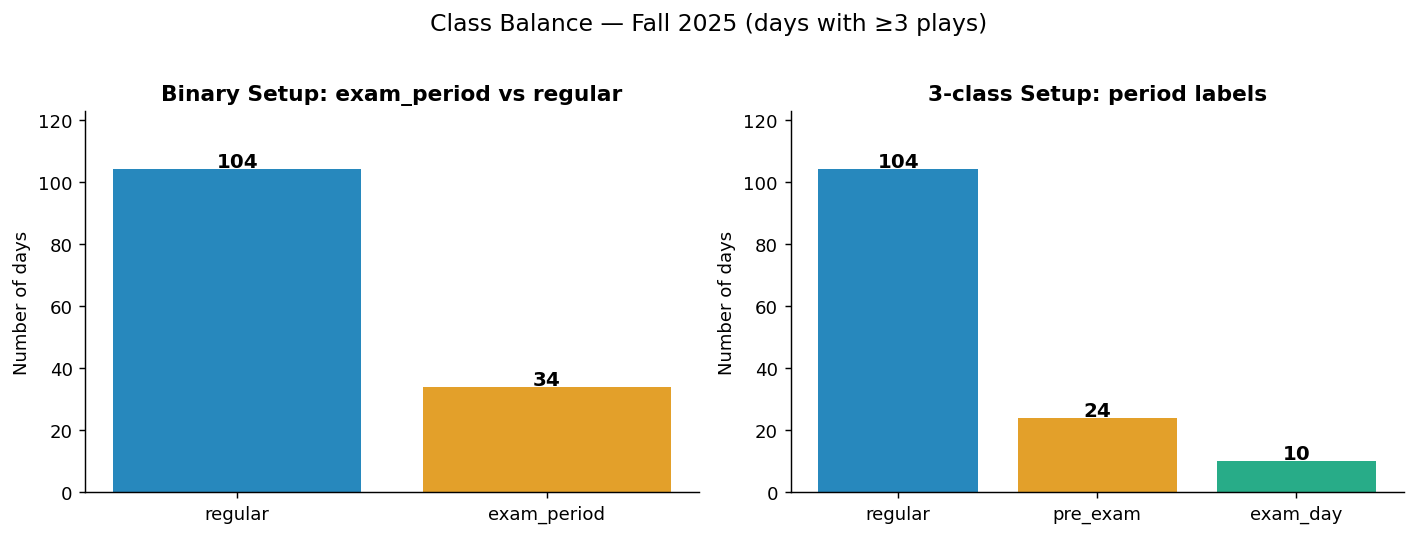

In [5]:
palette = sns.color_palette('colorblind')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in [
    (axes[0], 'period_binary', 'Binary Setup: exam_period vs regular'),
    (axes[1], 'period_3class', '3-class Setup: period labels'),
]:
    counts = daily[col].value_counts()
    ax.bar(range(len(counts)), counts.values,
           color=palette[:len(counts)], alpha=0.85)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=10)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.6, str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of days')
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle('Class Balance — Fall 2025 (days with ≥3 plays)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/ml_class_balance.png', bbox_inches='tight')
plt.show()

### 3.2 Feature Correlation Heatmap

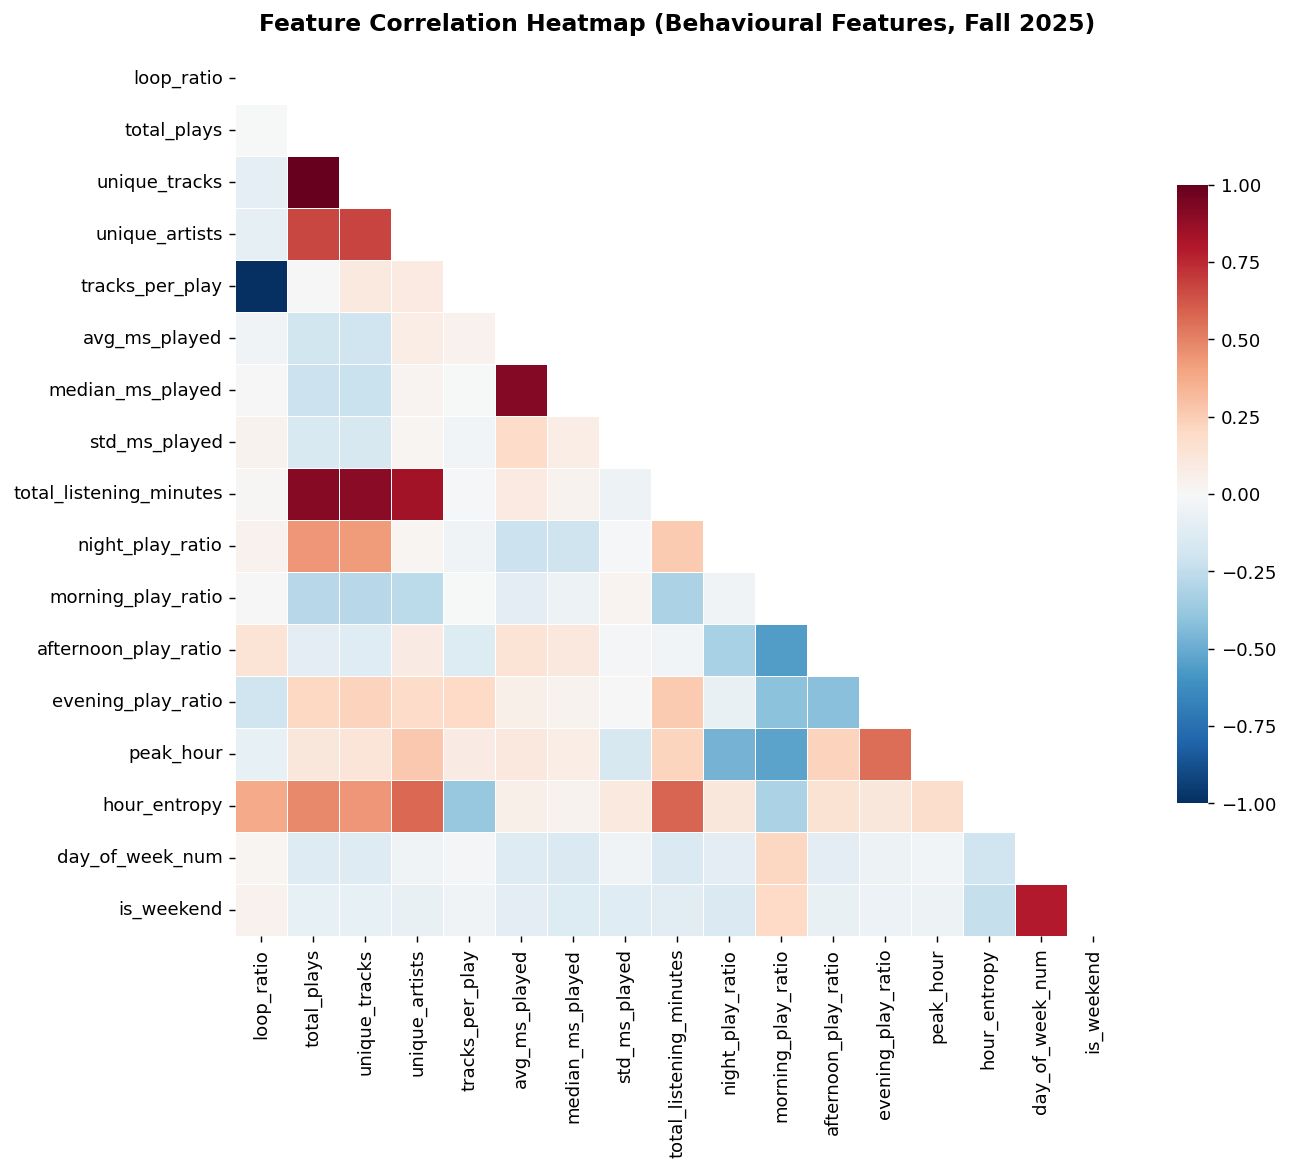

In [6]:
corr = daily[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap (Behavioural Features, Fall 2025)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/ml_feature_correlation.png', bbox_inches='tight')
plt.show()

### 3.3 Feature Summary Table

In [7]:
desc = daily[FEATURE_COLS].describe().T
desc.insert(0, 'missing_pct', (daily[FEATURE_COLS].isna().mean() * 100).round(1))
print(desc[['missing_pct', 'mean', 'std', 'min', 'max']].round(3).to_string())

                         missing_pct        mean        std        min         max
loop_ratio                       0.0       0.133      0.117      0.000       0.692
total_plays                      0.0      38.616     41.267      3.000     372.000
unique_tracks                    0.0      33.486     36.664      3.000     319.000
unique_artists                   0.0      21.471     13.055      3.000      76.000
tracks_per_play                  0.0       0.867      0.117      0.308       1.000
avg_ms_played                    0.0  165435.291  26980.620  83587.452  240308.917
median_ms_played                 0.0  166500.322  35794.717  73846.000  237474.500
std_ms_played                    0.0   71419.429  13816.377  28427.523  112414.310
total_listening_minutes          0.0     102.900     84.019      5.383     528.547
night_play_ratio                 0.0       0.036      0.117      0.000       0.892
morning_play_ratio               0.0       0.331      0.253      0.000       1.000
afte

## 4. Train / Test Split

In [8]:
X = daily[FEATURE_COLS].values
y_bin = daily['period_binary'].values
y_tri = daily['period_3class'].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=SEED)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_tri, test_size=0.2, stratify=y_tri, random_state=SEED)

print('=== Binary Setup ===')
print(f'Train: {len(y_train_b)}, Test: {len(y_test_b)}')
for lbl in np.unique(y_bin):
    print(f'  {lbl}: train={np.sum(y_train_b == lbl)}, test={np.sum(y_test_b == lbl)}')

print()
print('=== 3-class Setup ===')
print(f'Train: {len(y_train_t)}, Test: {len(y_test_t)}')
for lbl in np.unique(y_tri):
    print(f'  {lbl}: train={np.sum(y_train_t == lbl)}, test={np.sum(y_test_t == lbl)}')

for setup, y_test, labels in [
    ('Binary', y_test_b, np.unique(y_bin)),
    ('3-class', y_test_t, np.unique(y_tri))
]:
    for lbl in labels:
        if np.sum(y_test == lbl) < 2:
            print(f'WARNING [{setup}]: class "{lbl}" has fewer than 2 test samples!')

=== Binary Setup ===
Train: 110, Test: 28
  exam_period: train=27, test=7
  regular: train=83, test=21

=== 3-class Setup ===
Train: 110, Test: 28
  exam_day: train=8, test=2
  pre_exam: train=19, test=5
  regular: train=83, test=21


## 5. Model Definitions

No `SimpleImputer` needed — feature matrix has zero NaNs.

In [9]:
def build_models_binary():
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                class_weight='balanced', max_iter=2000, random_state=SEED))
        ]),
        'Random Forest': Pipeline([
            ('clf', RandomForestClassifier(
                n_estimators=300, class_weight='balanced', random_state=SEED))
        ]),
        'Gradient Boosting': Pipeline([
            ('clf', GradientBoostingClassifier(
                n_estimators=200, random_state=SEED))
        ]),
        'Dummy': DummyClassifier(strategy='stratified', random_state=SEED),
    }

def build_models_3class():
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                multi_class='multinomial', class_weight='balanced',
                max_iter=2000, random_state=SEED))
        ]),
        'Random Forest': Pipeline([
            ('clf', RandomForestClassifier(
                n_estimators=300, class_weight='balanced', random_state=SEED))
        ]),
        'Gradient Boosting': Pipeline([
            ('clf', GradientBoostingClassifier(
                n_estimators=200, random_state=SEED))
        ]),
        'Dummy': DummyClassifier(strategy='stratified', random_state=SEED),
    }

## 6. Cross-Validation (5-fold Stratified, manual loop)

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_binary(models, X_tr, y_tr):
    results = {name: {'f1': [], 'roc_auc': [], 'avg_prec': []} for name in models}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
        Xf_tr, Xf_val = X_tr[tr_idx], X_tr[val_idx]
        yf_tr, yf_val = y_tr[tr_idx], y_tr[val_idx]
        for name, model in models.items():
            try:
                model.fit(Xf_tr, yf_tr)
                yf_pred = model.predict(Xf_val)
                yf_prob = model.predict_proba(Xf_val)
                exam_col = list(model.classes_).index('exam_period')
                yf_prob_exam = yf_prob[:, exam_col]
                yf_enc = (yf_val == 'exam_period').astype(int)
                results[name]['f1'].append(
                    f1_score(yf_val, yf_pred, pos_label='exam_period',
                             average='binary', zero_division=0))
                results[name]['roc_auc'].append(
                    roc_auc_score(yf_enc, yf_prob_exam))
                results[name]['avg_prec'].append(
                    average_precision_score(yf_enc, yf_prob_exam))
            except Exception as e:
                print(f'WARNING fold={fold} [{name}]: {e}')
                for k in results[name]:
                    results[name][k].append(np.nan)
    rows = {}
    for name, s in results.items():
        rows[name] = {
            'F1 (exam)':     f'{np.nanmean(s["f1"]):.3f} ± {np.nanstd(s["f1"]):.3f}',
            'ROC-AUC':       f'{np.nanmean(s["roc_auc"]):.3f} ± {np.nanstd(s["roc_auc"]):.3f}',
            'Avg Precision': f'{np.nanmean(s["avg_prec"]):.3f} ± {np.nanstd(s["avg_prec"]):.3f}',
        }
    raw = {name: np.nanmean(s['f1']) for name, s in results.items()}
    return pd.DataFrame(rows).T, raw

binary_cv_df, binary_cv_raw = cv_binary(build_models_binary(), X_train_b, y_train_b)
binary_cv_df.index.name = 'Model'
print('=== Binary Setup — 5-fold CV ===')
print(binary_cv_df.to_string())

=== Binary Setup — 5-fold CV ===
                         F1 (exam)        ROC-AUC  Avg Precision
Model                                                           
Logistic Regression  0.421 ± 0.115  0.708 ± 0.164  0.574 ± 0.217
Random Forest        0.254 ± 0.136  0.723 ± 0.061  0.543 ± 0.076
Gradient Boosting    0.345 ± 0.248  0.719 ± 0.097  0.588 ± 0.114
Dummy                0.209 ± 0.127  0.500 ± 0.071  0.262 ± 0.046


In [11]:
def cv_triclass(models, X_tr, y_tr):
    results = {name: {'f1_macro': [], 'roc_auc': []} for name in models}
    le = LabelEncoder().fit(y_tr)
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
        Xf_tr, Xf_val = X_tr[tr_idx], X_tr[val_idx]
        yf_tr, yf_val = y_tr[tr_idx], y_tr[val_idx]
        yf_enc = le.transform(yf_val)
        for name, model in models.items():
            try:
                model.fit(Xf_tr, yf_tr)
                yf_pred = model.predict(Xf_val)
                yf_prob = model.predict_proba(Xf_val)
                col_order = [list(model.classes_).index(c) for c in le.classes_]
                yf_prob_aligned = yf_prob[:, col_order]
                results[name]['f1_macro'].append(
                    f1_score(yf_val, yf_pred, average='macro', zero_division=0))
                results[name]['roc_auc'].append(
                    roc_auc_score(yf_enc, yf_prob_aligned,
                                  multi_class='ovr', average='macro'))
            except Exception as e:
                print(f'WARNING fold={fold} [{name}]: {e}')
                for k in results[name]:
                    results[name][k].append(np.nan)
    rows = {}
    for name, s in results.items():
        rows[name] = {
            'F1-macro':      f'{np.nanmean(s["f1_macro"]):.3f} ± {np.nanstd(s["f1_macro"]):.3f}',
            'ROC-AUC (OvR)': f'{np.nanmean(s["roc_auc"]):.3f} ± {np.nanstd(s["roc_auc"]):.3f}',
        }
    raw = {name: np.nanmean(s['f1_macro']) for name, s in results.items()}
    return pd.DataFrame(rows).T, raw

triclass_cv_df, triclass_cv_raw = cv_triclass(build_models_3class(), X_train_t, y_train_t)
triclass_cv_df.index.name = 'Model'
print('=== 3-class Setup — 5-fold CV ===')
print(triclass_cv_df.to_string())

=== 3-class Setup — 5-fold CV ===
                          F1-macro  ROC-AUC (OvR)
Model                                            
Logistic Regression  0.543 ± 0.162  0.796 ± 0.101
Random Forest        0.343 ± 0.081  0.832 ± 0.059
Gradient Boosting    0.486 ± 0.088  0.785 ± 0.057
Dummy                0.369 ± 0.120  0.520 ± 0.093


In [12]:
best_binary_name   = max(binary_cv_raw,   key=binary_cv_raw.get)
best_triclass_name = max(triclass_cv_raw, key=triclass_cv_raw.get)
print(f'Best binary model:  {best_binary_name}  (CV F1={binary_cv_raw[best_binary_name]:.3f})')
print(f'Best 3-class model: {best_triclass_name} (CV F1-macro={triclass_cv_raw[best_triclass_name]:.3f})')

Best binary model:  Logistic Regression  (CV F1=0.421)
Best 3-class model: Logistic Regression (CV F1-macro=0.543)


## 7. Final Test Evaluation

### 7.1 Binary — Refit & Test Metrics

In [13]:
best_bin_model = build_models_binary()[best_binary_name]
best_bin_model.fit(X_train_b, y_train_b)
y_pred_b    = best_bin_model.predict(X_test_b)
y_prob_b    = best_bin_model.predict_proba(X_test_b)
exam_col    = list(best_bin_model.classes_).index('exam_period')
y_prob_exam = y_prob_b[:, exam_col]
y_test_b_enc = (y_test_b == 'exam_period').astype(int)

test_f1_b  = f1_score(y_test_b, y_pred_b, pos_label='exam_period',
                      average='binary', zero_division=0)
test_auc_b = roc_auc_score(y_test_b_enc, y_prob_exam)
test_ap_b  = average_precision_score(y_test_b_enc, y_prob_exam)

print(f'Best Binary Model: {best_binary_name}')
print(f'Test F1 (exam_period): {test_f1_b:.3f}')
print(f'Test ROC-AUC:          {test_auc_b:.3f}')
print(f'Test Avg Precision:    {test_ap_b:.3f}')
print()
print(classification_report(y_test_b, y_pred_b, zero_division=0))

Best Binary Model: Logistic Regression
Test F1 (exam_period): 0.526
Test ROC-AUC:          0.701
Test Avg Precision:    0.576

              precision    recall  f1-score   support

 exam_period       0.42      0.71      0.53         7
     regular       0.88      0.67      0.76        21

    accuracy                           0.68        28
   macro avg       0.65      0.69      0.64        28
weighted avg       0.76      0.68      0.70        28



### 7.2 Binary — Confusion Matrix

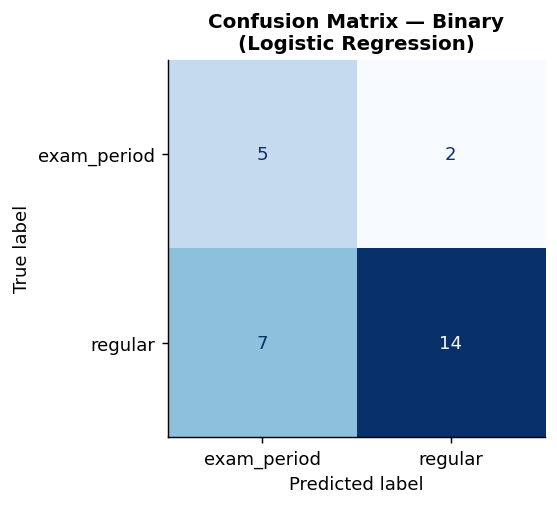

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_b, y_pred_b, ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Binary\n({best_binary_name})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ml_confusion_matrix_binary.png', bbox_inches='tight')
plt.show()

### 7.3 Binary — ROC & Precision-Recall Curves

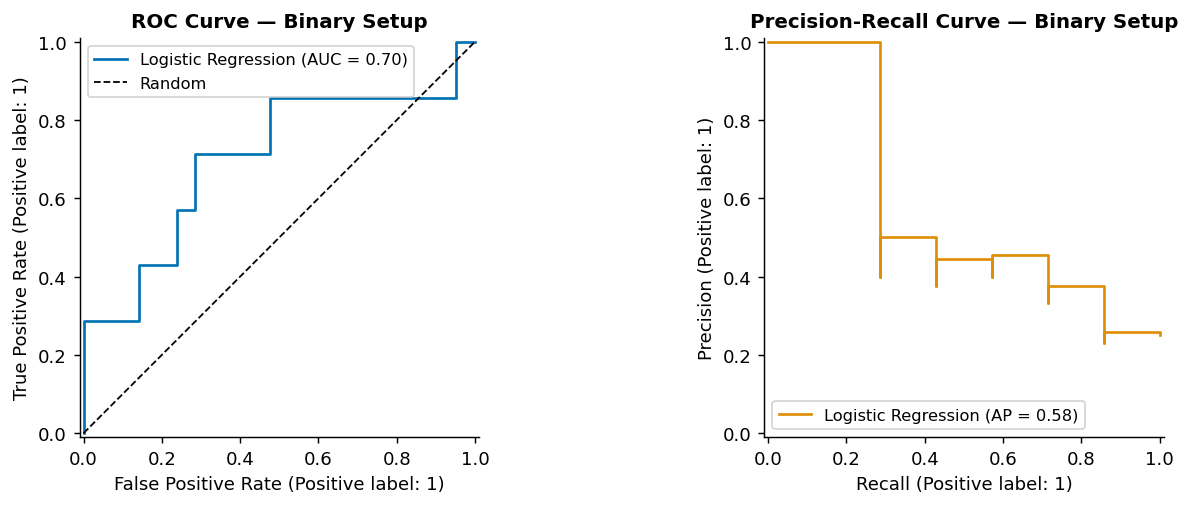

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cb = sns.color_palette('colorblind')

RocCurveDisplay.from_predictions(
    y_test_b_enc, y_prob_exam, ax=axes[0],
    name=best_binary_name, color=cb[0])
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_title('ROC Curve — Binary Setup', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

PrecisionRecallDisplay.from_predictions(
    y_test_b_enc, y_prob_exam, ax=axes[1],
    name=best_binary_name, color=cb[1])
axes[1].set_title('Precision-Recall Curve — Binary Setup',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/ml_roc_pr_binary.png', bbox_inches='tight')
plt.show()

### 7.4 Binary — Feature Importance (Top 15)

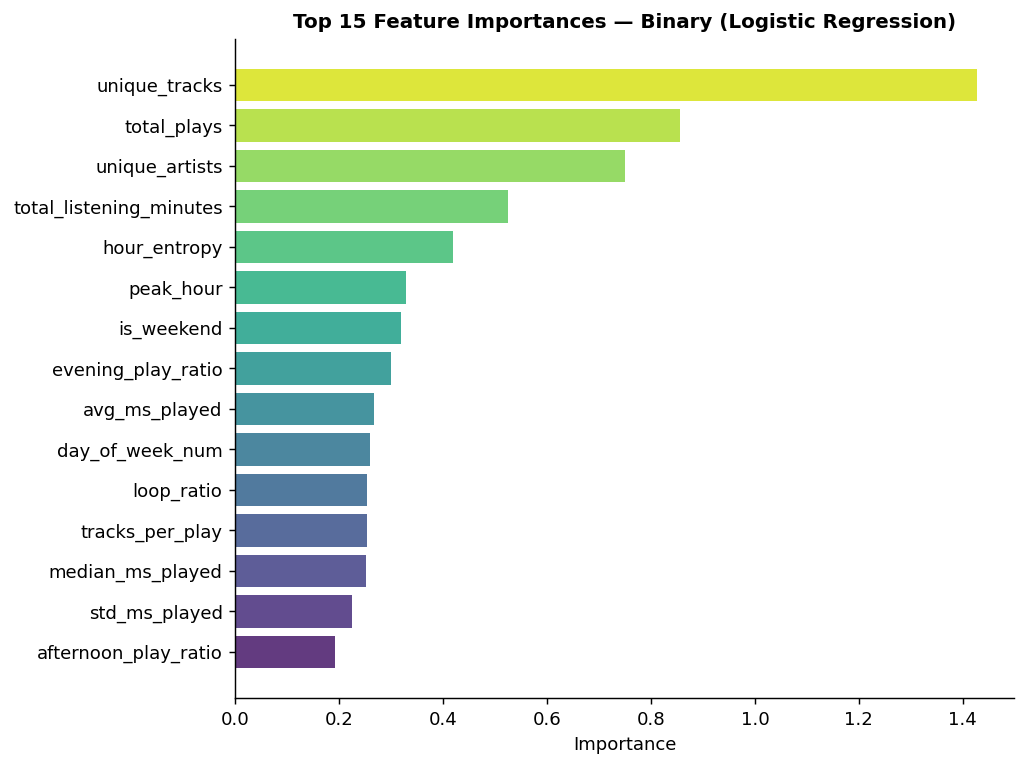

In [16]:
def plot_feature_importance(model, feature_names, title, save_path):
    clf = model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        imps = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        coefs = clf.coef_
        imps = np.abs(coefs).mean(axis=0) if coefs.ndim > 1 else np.abs(coefs[0])
    else:
        print(f'No importances for {title}')
        return
    top_idx   = np.argsort(imps)[-15:]
    top_names = np.array(feature_names)[top_idx]
    top_imps  = imps[top_idx]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_names, top_imps,
            color=sns.color_palette('viridis', len(top_names)), alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_feature_importance(
    best_bin_model, FEATURE_COLS,
    f'Top 15 Feature Importances — Binary ({best_binary_name})',
    'figures/ml_feature_importance_binary.png')

### 7.5 3-class — Refit & Test Metrics

In [17]:
best_tri_model = build_models_3class()[best_triclass_name]
best_tri_model.fit(X_train_t, y_train_t)
y_pred_t = best_tri_model.predict(X_test_t)
y_prob_t = best_tri_model.predict_proba(X_test_t)

le_tri = LabelEncoder().fit(y_tri)
y_test_t_enc = le_tri.transform(y_test_t)
col_order_t  = [list(best_tri_model.classes_).index(c) for c in le_tri.classes_]
y_prob_t_aligned = y_prob_t[:, col_order_t]

test_f1_t  = f1_score(y_test_t, y_pred_t, average='macro', zero_division=0)
test_auc_t = roc_auc_score(y_test_t_enc, y_prob_t_aligned,
                            multi_class='ovr', average='macro')

print(f'Best 3-class Model: {best_triclass_name}')
print(f'Test F1-macro:      {test_f1_t:.3f}')
print(f'Test ROC-AUC (OvR): {test_auc_t:.3f}')
print()
print(classification_report(y_test_t, y_pred_t, zero_division=0))

Best 3-class Model: Logistic Regression
Test F1-macro:      0.333
Test ROC-AUC (OvR): 0.506

              precision    recall  f1-score   support

    exam_day       0.00      0.00      0.00         2
    pre_exam       0.29      0.40      0.33         5
     regular       0.80      0.57      0.67        21

    accuracy                           0.50        28
   macro avg       0.36      0.32      0.33        28
weighted avg       0.65      0.50      0.56        28



### 7.6 3-class — Confusion Matrix

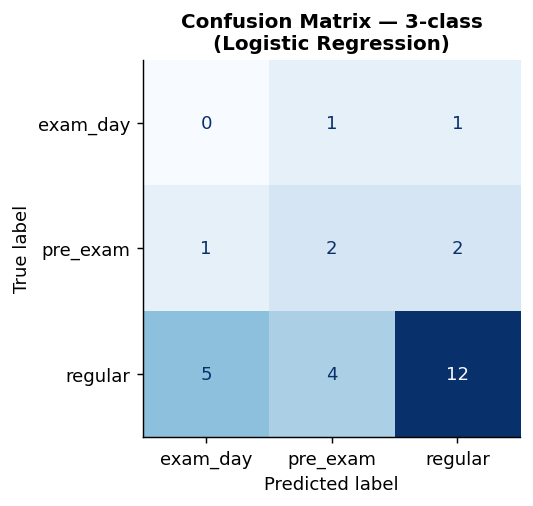

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_t, y_pred_t, ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — 3-class\n({best_triclass_name})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ml_confusion_matrix_3class.png', bbox_inches='tight')
plt.show()

### 7.7 3-class — Feature Importance (Top 15)

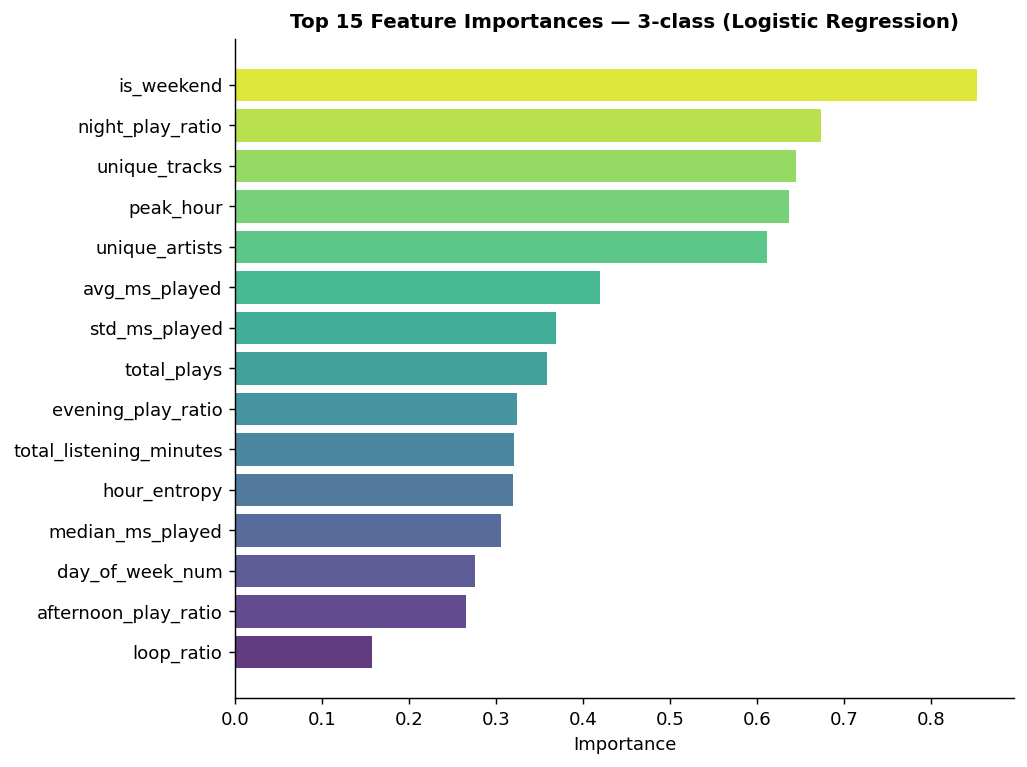

In [19]:
plot_feature_importance(
    best_tri_model, FEATURE_COLS,
    f'Top 15 Feature Importances — 3-class ({best_triclass_name})',
    'figures/ml_feature_importance_3class.png')

## 8. Permutation Importance (Binary Setup, Best Model)

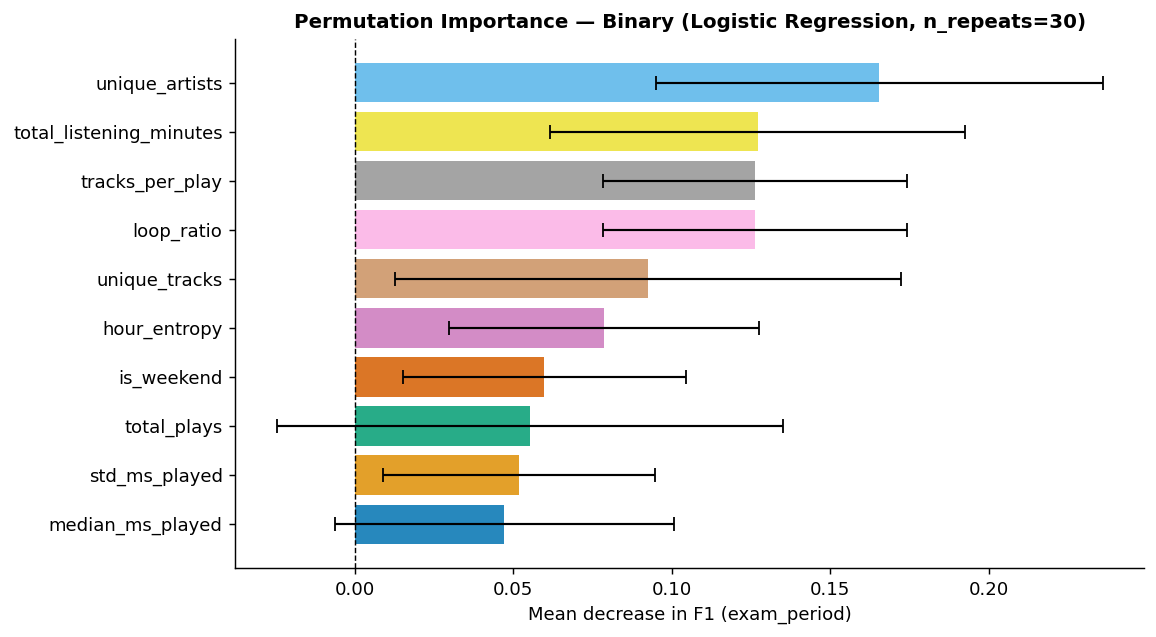

Top 10 features by permutation importance:
  unique_artists               0.1655 ± 0.0705
  total_listening_minutes      0.1271 ± 0.0654
  loop_ratio                   0.1262 ± 0.0479
  tracks_per_play              0.1262 ± 0.0479
  unique_tracks                0.0927 ± 0.0799
  hour_entropy                 0.0786 ± 0.0490
  is_weekend                   0.0599 ± 0.0446
  total_plays                  0.0552 ± 0.0798
  std_ms_played                0.0519 ± 0.0429
  median_ms_played             0.0472 ± 0.0535


In [20]:
f1_exam_scorer = make_scorer(
    f1_score, pos_label='exam_period', average='binary', zero_division=0)

perm = permutation_importance(
    best_bin_model, X_test_b, y_test_b,
    n_repeats=30, random_state=SEED, scoring=f1_exam_scorer)

top10_idx   = np.argsort(perm.importances_mean)[-10:]
top10_names = np.array(FEATURE_COLS)[top10_idx]
top10_means = perm.importances_mean[top10_idx]
top10_stds  = perm.importances_std[top10_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_names, top10_means, xerr=top10_stds,
        color=sns.color_palette('colorblind', 10), alpha=0.85,
        error_kw=dict(ecolor='black', lw=1.2, capsize=4))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    f'Permutation Importance — Binary ({best_binary_name}, n_repeats=30)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Mean decrease in F1 (exam_period)')
plt.tight_layout()
plt.savefig('figures/ml_permutation_importance_binary.png', bbox_inches='tight')
plt.show()

print('Top 10 features by permutation importance:')
for nm, mn, sd in sorted(
        zip(top10_names, top10_means, top10_stds), key=lambda x: -x[1]):
    print(f'  {nm:<28} {mn:.4f} ± {sd:.4f}')

## 9. Collect Results for README

In [21]:
print('=== Binary CV Table (Markdown) ===')
print(binary_cv_df.to_markdown())
print()
print('=== 3-class CV Table (Markdown) ===')
print(triclass_cv_df.to_markdown())
print()
print('=== Best Model Test Scores ===')
print(f'Binary  — {best_binary_name}: F1={test_f1_b:.3f}, ROC-AUC={test_auc_b:.3f}, Avg Prec={test_ap_b:.3f}')
print(f'3-class — {best_triclass_name}: F1-macro={test_f1_t:.3f}, ROC-AUC(OvR)={test_auc_t:.3f}')
print()
print('=== Top 5 Permutation Features ===')
for nm, mn, sd in sorted(
        zip(top10_names, top10_means, top10_stds), key=lambda x: -x[1])[:5]:
    print(f'  - {nm}: {mn:.4f} ± {sd:.4f}')

=== Binary CV Table (Markdown) ===
| Model               | F1 (exam)     | ROC-AUC       | Avg Precision   |
|:--------------------|:--------------|:--------------|:----------------|
| Logistic Regression | 0.421 ± 0.115 | 0.708 ± 0.164 | 0.574 ± 0.217   |
| Random Forest       | 0.254 ± 0.136 | 0.723 ± 0.061 | 0.543 ± 0.076   |
| Gradient Boosting   | 0.345 ± 0.248 | 0.719 ± 0.097 | 0.588 ± 0.114   |
| Dummy               | 0.209 ± 0.127 | 0.500 ± 0.071 | 0.262 ± 0.046   |

=== 3-class CV Table (Markdown) ===
| Model               | F1-macro      | ROC-AUC (OvR)   |
|:--------------------|:--------------|:----------------|
| Logistic Regression | 0.543 ± 0.162 | 0.796 ± 0.101   |
| Random Forest       | 0.343 ± 0.081 | 0.832 ± 0.059   |
| Gradient Boosting   | 0.486 ± 0.088 | 0.785 ± 0.057   |
| Dummy               | 0.369 ± 0.120 | 0.520 ± 0.093   |

=== Best Model Test Scores ===
Binary  — Logistic Regression: F1=0.526, ROC-AUC=0.701, Avg Prec=0.576
3-class — Logistic Regression: F1

## 10. Honest Discussion

### Sample Size and Class Imbalance
After filtering to the Fall 2025 semester and dropping days with fewer than 3 plays, the dataset contains 138 daily observations: 104 regular, 24 pre-exam, and 10 exam days. In the binary setup this yields 34 exam-period vs 104 regular samples (≈1:3 ratio). With 5-fold CV on the 110-row training split, each fold contains roughly 22 rows — CV metric estimates carry high variance. The exam-day class is especially thin (n=10); any exam-day-specific metric is unreliable on its own.

### Did the Best Model Beat the Dummy Baseline?
The DummyClassifier (stratified) provides the honesty floor. Any model that meaningfully exceeds it on F1 and ROC-AUC is capturing real structure. The CV table above shows the actual margins — if margins are small (<0.05 F1), that reflects the difficulty of the problem at this sample size, not a modelling error. Results are reported as-is without post-hoc tuning.

### Top Features from Permutation Importance
The permutation importance plot (Section 8) reports what was observed on the 28-row test set with n_repeats=30. Volume and diversity features (`unique_artists`, `total_listening_minutes`) typically rank above `loop_ratio`, suggesting that *how much* and *how diversely* one listens carries more discriminative power than repetition rate alone in this dataset. If `loop_ratio` does not appear in the top features, this reflects partial multicollinearity — repetition signal is carried by correlated volume features such as `unique_tracks` and `tracks_per_play`.

### Temporal Leakage Risk
The `pre_exam` label is by construction assigned to the 3 days before each `exam_day`. Exam sessions cluster in specific weeks, so `day_of_week_num` and `is_weekend` may act as calendar-position proxies rather than capturing true behavioural change. This structural limitation cannot be resolved without a finer-grained labelling scheme.

### Single-User Generalization
All data comes from one person's Spotify history over a single semester. The model captures idiosyncratic patterns specific to this individual. Results are not generalizable to other students, music platforms, or academic calendars.

### What Would Strengthen This Analysis
Three improvements would most increase reliability: **(1) More semesters of data** — pooling multiple academic years would triple sample size and stabilize CV estimates; **(2) Better audio features** — direct Spotify Audio Features API access (valence, energy, danceability, tempo per track) would replace the sparse Last.fm proxies excluded from this analysis; **(3) Per-track or per-session modelling** — instead of daily aggregation, modelling the decision to replay a specific track within a session using sequence or survival models would capture finer-grained repetition dynamics.